# TP1 : Formation des images et modélisation géométrique de la caméra



## Objectifs pédagogiques

À l’issue de ce TP, vous serez capable de :

* Comprendre le **modèle de formation des images** par une caméra
* Modéliser une caméra par le **modèle sténopé**
* Manipuler les notions de **géométrie projective**
* Appliquer des **transformations géométriques 2D et 3D**


## Contexte

Les systèmes de vision artificielle reposent sur une modélisation géométrique précise du passage du monde réel 3D vers l’image 2D. Ce TP propose une approche progressive, allant du modèle théorique du sténopé à une compréhension des transformation géomètriques.

Nous allons commencer par importer les packages.


In [1]:
# Importer les packages nécessaires pour ce TP
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

## Partie 1 – Manipulation d'images

Nous allons commencer par un petit exercice tout simple vous permettant de prendre un peu la main sur les images. L'objectif est d'appliquer une méthode appelée l'incrustation (Chroma Key) afin d'intégrer un arrière plan sur une image pour simuler un fond vert.

Commencer par charger l'image *unwanted.jpg* puis insérer l'image *background.jpg* comme arrière plan.

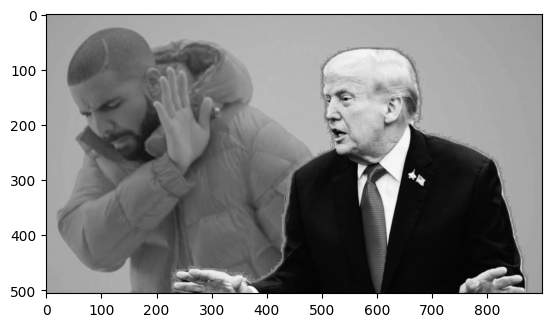

In [2]:
#A compléter
#Importer l'image
path_base = 'Base_images/'
img_u = cv2.imread(path_base+'unwanted.jpg',0) 
img_b = cv2.imread(path_base+'background.png',0) 

#Traitement et mise en place du background

img_u = cv2.resize(img_u, (900, 506))
img_b = cv2.resize(img_b, (900, 506))

for i in range(506):
    for j in range(900):
        if img_u[i,j] == 143:
            img_u[i,j] = img_b[i,j]

#Affichage du résultat
plt.imshow(img_u,'gray')


## Partie 2 – Formation des images : modèle sténopé

### 1.1 Principe du sténopé

* Schéma du modèle sténopé
* Notions de plan image, centre optique, focale
* Projection d’un point 3D (P(X,Y,Z)) sur le plan image



**Travail demandé**

* Implémenter la projection sténopé en Python
* Étudier l’effet de la focale sur l’image

Importer l'image *lady.jpg* et affichez la. Pensez à la mettre en BGR pour qu'elle soit affichée correctement. La lecture de l'image doit être faite en utilisant le format image PIL. 

Pour plus d'informations concernant l'image PIL: https://pillow.readthedocs.io/en/stable/reference/Image.html

(1000, 667, 3)


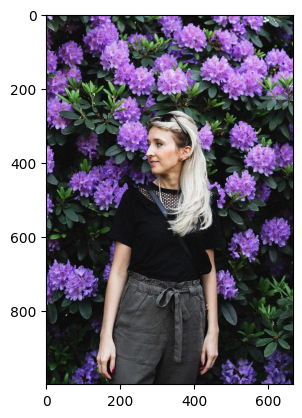

In [3]:
# Importer et afficher l'image lady.png
img = cv2.imread(path_base+'lady.jpg',-1) 
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)
# Afficher l'image
plt.imshow(img)

Cette image a l'avantage d'avoir toutes les métadonnées *EXIF*. Ces données peuvent être perçues avec un visualiseur EXIF ou en utilisant Pillow (PIL). Le code ci-dessous vous permet d'afficher ces informations.

In [4]:
from PIL import Image
from PIL.ExifTags import TAGS

img = Image.open(path_base+'lady.jpg')
exif_data = img._getexif()

for tag_id, value in exif_data.items():
    tag = TAGS.get(tag_id, tag_id)
    print(f"{tag}: {value}")


ResolutionUnit: 2
ExifOffset: 226
Make: SONY
Model: ILCE-7M2
Software: Adobe Photoshop Lightroom Classic 10.0 (Macintosh)
Orientation: 1
DateTime: 2020:11:22 09:35:45
XResolution: 240.0
YResolution: 240.0
ExifVersion: b'0231'
ShutterSpeedValue: 7.965784
ApertureValue: 2.970854
DateTimeOriginal: 2017:06:04 13:12:50
DateTimeDigitized: 2017:06:04 13:12:50
BrightnessValue: 5.0328125
ExposureBiasValue: 0.0
MaxApertureValue: 1.6953125
MeteringMode: 2
LightSource: 0
Flash: 16
FocalLength: 55.0
ColorSpace: 1
ExifImageWidth: 667
FocalPlaneXResolution: 1675.2573852539062
FocalPlaneYResolution: 1675.2573852539062
OffsetTime: +01:00
ExifImageHeight: 1000
FocalPlaneResolutionUnit: 3
Sharpness: 0
FileSource: b'\x03'
ExposureTime: 0.004
FNumber: 2.8
SceneType: b'\x01'
ExposureProgram: 3
CustomRendered: 0
ISOSpeedRatings: 100
ExposureMode: 0
FlashPixVersion: b'0100'
SensitivityType: 2
WhiteBalance: 0
RecommendedExposureIndex: 100
LensSpecification: (55.0, 55.0, 1.8, 1.8)
LensModel: FE 55mm F1.8 ZA
Dig

**Question**: Quelles sont les valeurs de la focale, taille et resolution de l'image? Notez que la focale est exprimée en *mm*

*Réponse*: FocalLength: 55.0, XResolution: 240.0, YResolution: 240.0, Size: 1000x667 px

Pour passer de la focale en *mm* à la focale en pixels, il faut appliquer une transfomration. Soient :

- $f_{mm}$ : focale en millimètres (EXIF)
- $W_{mm}$ : largeur du capteur (en mm)
- $W_{px}$ : largeur de l’image (en pixels)

La focale en pixels est donnée par :

$$
f_{px} = \frac{f_{mm}}{W_{mm}} \times W_{px}
$$


Cette relation suppose que les pixels sont carrés et que l’axe optique est aligné avec le centre de l’image.

*N.B.* La taille du capteur Sony A7 II correspond au plein format (Full frame) : 35.8mm x 23.9mm


In [5]:
def focal_mm_to_px(f_mm, sensor_width_mm, image_width_px):
    f_px = f_mm*image_width_px/sensor_width_mm
    return f_px


Quelle est la valeur de la focale en pixels?

In [6]:
# A compléter
f_mm = 55.0
sensor_width_mm = 36
image_width_px = 667
f_px = focal_mm_to_px(f_mm, sensor_width_mm, image_width_px)

print(f_px)

1019.0277777777778


Dans cette partie, nous allons analyser les principes de base introduits en cours pour représenter la relation entre un point 3D (P(X,Y,Z)). Compléter la fonction suivante pour retourner les coordonnées du point sur le plan image. c_x et c_y sont les coordonnées du centre optique.

In [7]:
def projection_stenope(P, f, cx, cy):
    X, Y, Z = P
    u = f * X / Z + cx
    v = f * Y / Z + cy
    return (u, v)

Supposons que le point 3D est à un mètre devant la caméra, 5 cm à droite et 3cm vers le haut. Trouvez les coordonnées en pixel du point 3D.

In [9]:
# A compléter
P = (0.05,0.03,1)
c_x = 667/2
c_y = 1000/2
f = 1024.72
u,v  =  projection_stenope(P, f, c_x, c_y)

print(u,", ",v)

384.736 ,  530.7416


Maintenant que vous avez les coordonnées, affichez-le sur l'image.

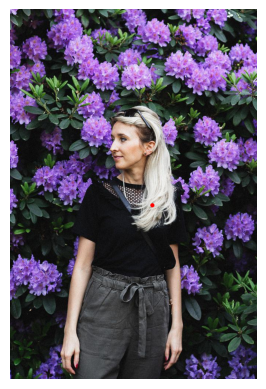

In [12]:
# A compléter
from PIL import Image, ImageDraw

draw = ImageDraw.Draw(img)
r = 5
draw.ellipse((u-r, v-r, u+r, v+r), fill="red")


plt.imshow(img)
plt.axis("off")
plt.show()


**Question** Quel est l impact de la valeur de la focale sur l'image?

*Réponse*: la valeur focale influence la taille des objets dans l'image. Une focale courte agrandit la scène et une focale longue la compresse.

## Partie 2 – Géométrie projective

### 2.1 Coordonnées homogènes


Compléter pour afficher les coordonnées homogènes du point image:

In [ ]:
# A compléter


En s'appuyant sur ce qu'on a vu en cours, calculer et afficher la matrice intrinséque K

In [13]:
# A compléter
K = np.array([[f,0,c_x],[0,f,c_y],[0,0,1]])
print(K)

[[1.02472e+03 0.00000e+00 3.33500e+02]
 [0.00000e+00 1.02472e+03 5.00000e+02]
 [0.00000e+00 0.00000e+00 1.00000e+00]]


Exemple du cours: Reprenons la slide 27 du cours. On utilisera les paramètres suivants
- $\alpha_u = 1395$
- $\alpha_v = 1396$
- $u_0 = 681$
- $v_0 = 511$

Calculer la matrice K correspondante et affichez-la

In [15]:
#A compléter
alpha_u = 1395
alpha_v = 1396
u0 = 681
v0 = 511

K = np.array([[alpha_u, 0, u0],
              [0, alpha_v, v0],
              [0, 0, 1]])

print(K)


[[1395    0  681]
 [   0 1396  511]
 [   0    0    1]]


Projetez le point 3D en utilisant K et affichez le résultat

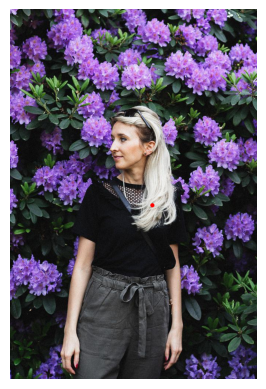

In [16]:
# A compléter
p = K @ P[:3]
u, v = p[0] / p[2], p[1] / p[2]

draw = ImageDraw.Draw(img)
r = 5
draw.ellipse((u-r, v-r, u+r, v+r), fill="red")


plt.imshow(img)
plt.axis("off")
plt.show()

Calculer la direction du rayon lumineux correspondant à un pixel. Concrêtement cela correspond à faire une projection inverse, c-à-d, retrouver la direction du rayon 3D associé.

Rétro-projection 2D ⟶ une droite en 3D

Un pixel ne correspond pas à un point unique en 3D, mais à une infinité de points alignés sur un rayon. On cherche donc la direction de ce rayon.

In [17]:
# A compléter
K_inv = np.linalg.inv(K)

p_pixel = np.array([u, v, 1])
direction = K_inv @ p_pixel
print("Direction du rayon lumineux :", direction)

Direction du rayon lumineux : [0.05 0.03 1.  ]


### 2.2 Propriétés de la projection
Soient trois points 3D alignés :
$P_1(0,0,1000),P_2(50,0,1000), P_3(100,0,1000)$
Montrer que leurs projections image sont également alignées.

In [18]:
# A compléter
P1 = np.array([0, 0, 1000, 1])
P2 = np.array([50, 0, 1000, 1])
P3 = np.array([100, 0, 1000, 1])


p1_proj = K @ P1[:3]
p2_proj = K @ P2[:3]
p3_proj = K @ P3[:3]

print(p1_proj, p2_proj, p3_proj)



[681000 511000   1000] [750750 511000   1000] [820500 511000   1000]


**Question:** Expliquer pourquoi l’alignement est un invariant projectif.

*Réponse*: 

## Partie 3 – Transformations géométriques 2D et 3D pour les paramètres extrinsèques

Maintenant que nous avons réussi à déterminer les paramètre intrinséques, nous allons effectuer l'étape suivant qui est d'appliquer une transformation spatiale. Cela correspond aux paramètres extirinsèques! 

### 3.1 Transformations 2D

Écrire la matrice de rotation 2D R(θ) en coordonnées homogènes.

In [19]:
def rotation_y(angle_deg):
  angle_rad = np.deg2rad(angle_deg)
  R = np.array([[np.cos(angle_rad), -np.sin(angle_rad), 0],
                  [np.sin(angle_rad), np.cos(angle_rad), 0],
                  [0, 0, 1]])

  return R


Ecrire une fonction qui retourne le vecteur de translation $t$ à partir d'un point.

In [20]:
def compute_t_from_one_point(P, P_target, angle_deg):
    t = P_target - P
    return t


Ecrire une fonction décrivant la matrice de transformation rigide ([R|t])

In [21]:
def build_T(R, t):
    T = np.hstack((R, t.reshape(-1, 1)))

    return T


Appliquer à un exemple concret avec une rotation imposée à $20^o$ et un point initial $P =(100,0,1000)$ et un point cible imposé $P =(0,0,1200)$. Afficher R, t et la matrice de transofrmation rigide.

In [22]:
# A compléter
angle_deg = 20
P = np.array([100, 0, 1000])
P_target = np.array([0, 0, 1200])


R = rotation_y(angle_deg)


t = compute_t_from_one_point(P, P_target,angle_deg)


T = build_T(R, t)


print("Matrice de rotation R :")
print(R)

print("\nVecteur de translation t :")
print(t)

print("\nMatrice de transformation rigide [R | t] :")
print(T)

Matrice de rotation R :
[[ 0.93969262 -0.34202014  0.        ]
 [ 0.34202014  0.93969262  0.        ]
 [ 0.          0.          1.        ]]

Vecteur de translation t :
[-100    0  200]

Matrice de transformation rigide [R | t] :
[[   0.93969262   -0.34202014    0.         -100.        ]
 [   0.34202014    0.93969262    0.            0.        ]
 [   0.            0.            1.          200.        ]]


Vérifier la projection et commenter le résultat


In [16]:
#A compléter


*Réponse:* 